In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('zomato.csv',encoding='latin-1')

In [3]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [4]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [5]:
df.shape

(51717, 17)

In [6]:
[f for f in df.columns if df[f].isnull().sum() > 0]

['rate',
 'phone',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)']

In [7]:
import seaborn as sns

<Axes: >

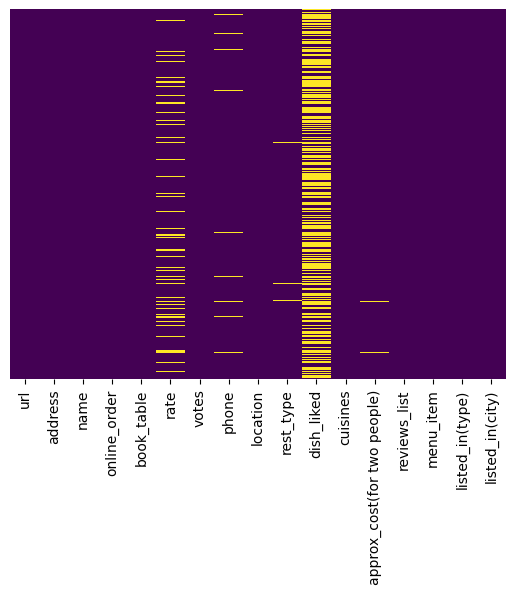

In [8]:
sns.heatmap(df.isnull(),yticklabels= False,cbar=False,cmap='viridis')

In [9]:
df=df.drop(columns=['url','address','phone','menu_item'],axis=True)

In [10]:
df.head()

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1/5,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1/5,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8/5,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,Grand Village,No,No,3.8/5,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari


In [11]:
df.dtypes

name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
reviews_list                   object
listed_in(type)                object
listed_in(city)                object
dtype: object

In [12]:
df['approx_cost(for two people)']=df['approx_cost(for two people)'].astype(str)
df['approx_cost(for two people)']= pd.to_numeric(df['approx_cost(for two people)'].apply(lambda x:x.replace(",","")),errors='coerce')

In [13]:
df.dtypes

name                            object
online_order                    object
book_table                      object
rate                            object
votes                            int64
location                        object
rest_type                       object
dish_liked                      object
cuisines                        object
approx_cost(for two people)    float64
reviews_list                    object
listed_in(type)                 object
listed_in(city)                 object
dtype: object

In [14]:
df=df[df['rate'].isna()==False]

In [15]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [16]:
df['rate']= df['rate'].apply(lambda x:x.split("/"))
df['rate']= pd.to_numeric(df['rate'].apply(lambda x:x[0].strip()),errors='coerce')

In [17]:
df['rate'].isna().sum()

2266

In [18]:
df.dropna(subset='rate',inplace=True)

In [19]:
df.sample(5)

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
31649,VRS Food Zone,Yes,No,3.3,5,Ejipura,Quick Bites,NaN,"Chinese, Fast Food",100.0,[],Dine-out,Koramangala 5th Block
14955,Amande Patisserie,Yes,No,4.2,231,Lavelle Road,"Bakery, Dessert Parlor","Macaroon, Fruit Tart, Opera Cake, Belgian Dark...","Bakery, French, Desserts",300.0,"[('Rated 4.0', 'RATED\n \nBlueberry &Belgium d...",Delivery,Frazer Town
34574,Aarya Pork Hotel,No,No,3.4,12,BTM,Quick Bites,NaN,"South Indian, Biryani, Chinese",300.0,"[('Rated 5.0', ""RATED\n Awesome food taste I ...",Dine-out,Koramangala 6th Block
35360,Sonar Bangala,Yes,No,3.8,75,Koramangala 5th Block,Quick Bites,"Kosha Mangsho, Daab Chingri, Fish Curry, Dum B...","Bengali, North Indian",500.0,"[('Rated 3.0', 'RATED\n Visited this place a ...",Delivery,Koramangala 7th Block
12024,Baskin Robbins,No,No,3.1,17,Vasanth Nagar,Dessert Parlor,NaN,"Ice Cream, Desserts",250.0,"[('Rated 2.0', ""RATED\n Ice creams are good a...",Delivery,Church Street


In [20]:
df['rate'].isnull().sum()
df['approx_cost(for two people)'].isnull().sum()


246

In [21]:
numeric_cols= df.select_dtypes(exclude=object).columns.to_list()
categoric_cols= df.select_dtypes(include=object).columns.to_list()

In [22]:
categoric_cols

['name',
 'online_order',
 'book_table',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'reviews_list',
 'listed_in(type)',
 'listed_in(city)']

In [23]:
cols=['name',
 'online_order',
 'book_table',
 'location',
 'rest_type',
 'dish_liked',
 'listed_in(type)',
 'listed_in(city)']

In [24]:
numeric_cols

['rate', 'votes', 'approx_cost(for two people)']

In [25]:
def column_analysis(cols,df):

    print("name of column :", cols)
    print("Number of unique values:", df[cols].nunique())
    print("which are:")
    print("Unique values:", df[cols].unique())
    print("*****************************")
for col in cols:
    column_analysis(col,df)
    
    

name of column : name
Number of unique values: 6649
which are:
Unique values: ['Jalsa' 'Spice Elephant' 'San Churro Cafe' ...
 'The Nest - The Den Bengaluru' 'Nawabs Empire' 'SeeYa Restaurant']
*****************************
name of column : online_order
Number of unique values: 2
which are:
Unique values: ['Yes' 'No']
*****************************
name of column : book_table
Number of unique values: 2
which are:
Unique values: ['Yes' 'No']
*****************************
name of column : location
Number of unique values: 92
which are:
Unique values: ['Banashankari' 'Basavanagudi' 'Mysore Road' 'Jayanagar'
 'Kumaraswamy Layout' 'Rajarajeshwari Nagar' 'Vijay Nagar' 'Uttarahalli'
 'JP Nagar' 'South Bangalore' 'City Market' 'Bannerghatta Road' 'BTM'
 'Kanakapura Road' 'Bommanahalli' 'Electronic City' 'Sarjapur Road'
 'Wilson Garden' 'Shanti Nagar' 'Koramangala 5th Block' 'Richmond Road'
 'HSR' 'Koramangala 7th Block' 'Bellandur' 'Marathahalli' 'Whitefield'
 'East Bangalore' 'Old Airport Road

In [26]:
df.describe()

,rate,votes,approx_cost(for two people)
count,41622.000000,41622.000000,41376.000000
mean,3.700526,351.861852,603.330578
std,0.440598,882.182990,464.388912
min,1.800000,0.000000,40.000000
25%,3.400000,21.000000,300.000000
50%,3.700000,73.000000,500.000000
75%,4.000000,276.750000,700.000000
max,4.900000,16832.000000,6000.000000


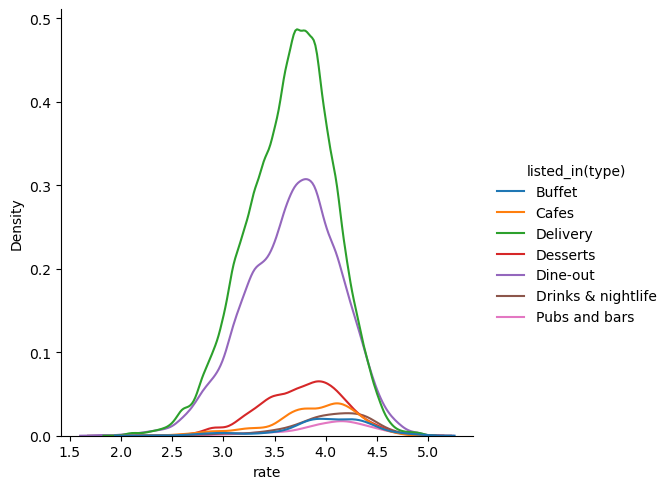

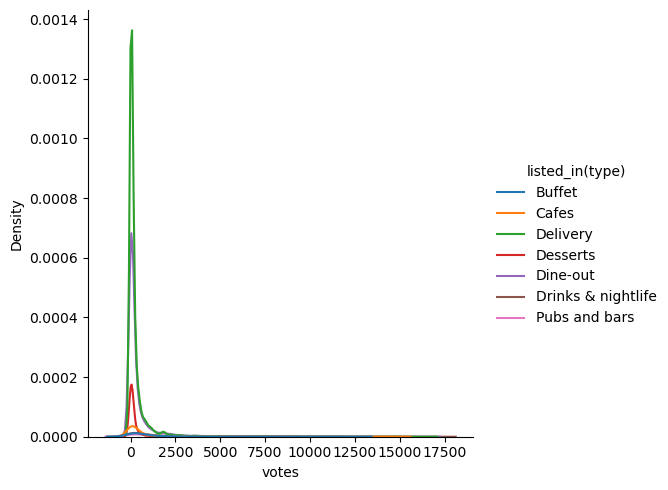

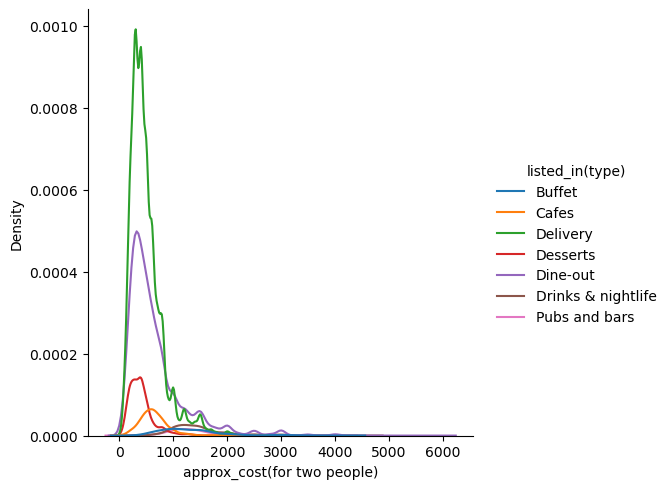

In [27]:
import matplotlib.pyplot as plt
def plots(df,x):
    sns.displot(df,x=cols,hue="listed_in(type)",kind="kde")
    plt.show()
for cols in numeric_cols:
    plots(df,cols)

In [28]:
categoric_cols

['name',
 'online_order',
 'book_table',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'reviews_list',
 'listed_in(type)',
 'listed_in(city)']

In [29]:
top_10= df.sort_values('rate').drop_duplicates('rate',keep='last').tail(10).sort_values(by='rate', ascending= False)

In [30]:
top_10

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
43055,Belgian Waffle Factory,Yes,No,4.9,1750,Brigade Road,Dessert Parlor,"Coffee, Berryblast, Nachos, Chocolate Waffles,...",Desserts,400.0,"[('Rated 4.0', ""RATED\n Looks like there's a ...",Desserts,MG Road
40485,Chili's American Grill & Bar,Yes,Yes,4.8,6440,Malleshwaram,"Casual Dining, Bar","Veg Platter, Burgers, Mushroom Soup, Cocktails...","American, Tex-Mex, Burger, BBQ, Mexican",1400.0,"[('Rated 2.0', ""RATED\n Pricey menu for the q...",Pubs and bars,Malleshwaram
29265,The Black Pearl,No,Yes,4.7,10512,Koramangala 5th Block,"Casual Dining, Bar","Chocolate Lollipop, Chocolate Biscuit, Fire Sh...","North Indian, European, Mediterranean",1400.0,"[('Rated 5.0', 'RATED\n Amazing experience am...",Buffet,Koramangala 5th Block
33653,Kurtoskalacs,No,No,4.6,272,Koramangala 5th Block,"Dessert Parlor, Quick Bites","Hazelnut Cappuccino, Pancakes, Nutella Shake, ...","Desserts, Fast Food",400.0,"[('Rated 4.0', ""RATED\n This place grabbed my...",Desserts,Koramangala 6th Block
37863,XO Belgian Waffle,Yes,No,4.5,221,Brigade Road,Food Court,"Belgian Waffles, Bubble Gum Shake, Hot Chocola...","Desserts, Beverages",450.0,"[('Rated 5.0', ""RATED\n XO Belgian Waffle has...",Delivery,Lavelle Road
12594,RockSalt,Yes,Yes,4.4,488,St. Marks Road,"Bar, Casual Dining","Roti, Cocktails, Chicken Biryani, Paratha, Dah...",Modern Indian,1900.0,"[('Rated 4.0', 'RATED\n What a great place ! ...",Dine-out,Church Street
43282,Double Decker,No,Yes,4.3,2716,Brigade Road,"Bar, Casual Dining","Bbq Pizza, Pasta, Sangria, Cocktails, Mocktail...","Continental, North Indian",1300.0,"[('Rated 4.0', ""RATED\n Very nice place and g...",Dine-out,MG Road
29367,Khatta Meetha Teekha,Yes,No,4.2,190,Koramangala 6th Block,Quick Bites,"Gulab Jamun, Raita, Chaat, Chole, Soya Chaap, ...","Street Food, North Indian, Mithai, Chinese, Be...",300.0,"[('Rated 4.0', ""RATED\n Few restaurants are l...",Delivery,Koramangala 5th Block
40981,Deli Chats and Sweets,Yes,No,4.1,50,Marathahalli,Quick Bites,"Chole, Samosa Chaat, Papdi Chaat, Dahipuri, Se...","Street Food, Mithai",200.0,"[('Rated 5.0', 'RATED\n When you wake in morn...",Delivery,Marathahalli
17831,Aagaman Veg,Yes,No,4.0,556,Indiranagar,Casual Dining,"Jalebi, Lunch Buffet, Dal Kichadi, Panneer But...","North Indian, Chinese, South Indian",900.0,"[('Rated 3.0', ""RATED\n Aagaman veg is a veg ...",Delivery,Indiranagar


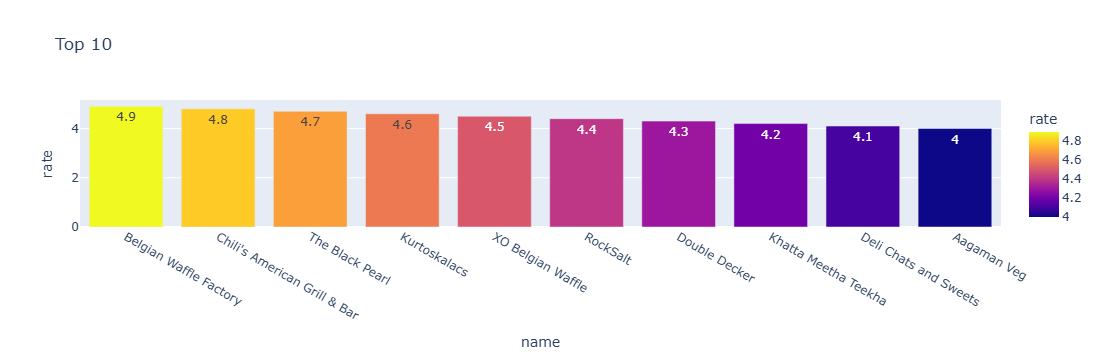

In [31]:
import plotly.express as px
label={"x":"Restaurant Name", "y": "Rates"}
fig=px.bar(top_10,
           x='name',
           y='rate',
           labels=label,
           text='rate',
           title='Top 10',
           color='rate')
fig.show()
           
           

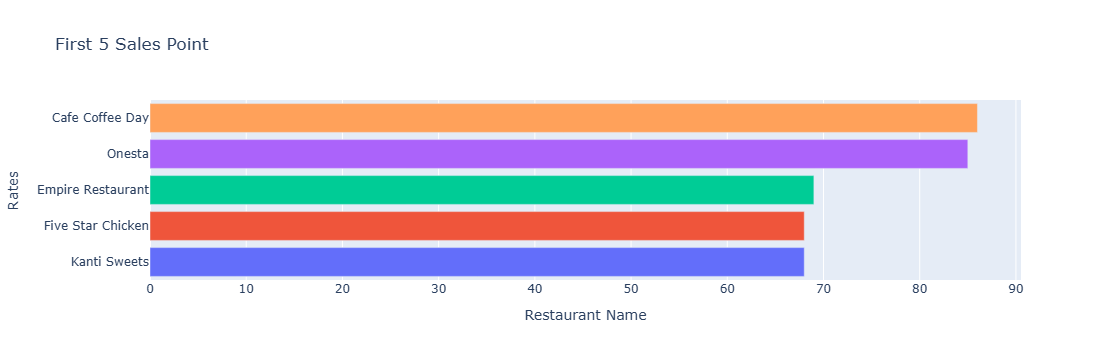

In [32]:
first_5= df['name'].value_counts()[:5].sort_values()

label={"x":"Restaurant Name", "y": "Rates"}

fig=px.bar( x=first_5.values, y= first_5.index, labels=label, title="First 5 Sales Point", color=first_5.index)
fig.update_layout(showlegend = False)
fig.show()

In [33]:
common5= first_5.index
common5_values= df[df['name'].isin(common5)]
common5_values= common5_values.groupby(by='name')['rate'].mean().sort_values()

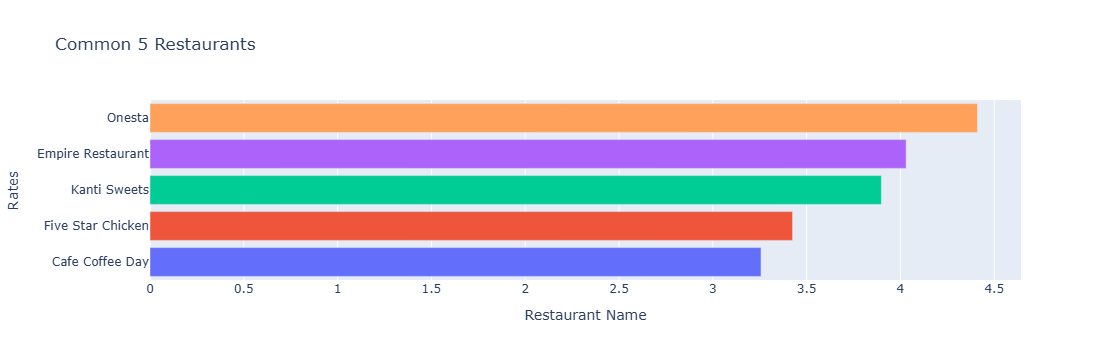

In [34]:
label={"x":"Restaurant Name", "y": "Rates"}

fig=px.bar( x=common5_values.values, y= common5_values.index, labels=label, title="Common 5 Restaurants", color=first_5.index)
fig.update_layout(showlegend = False)
fig.show()

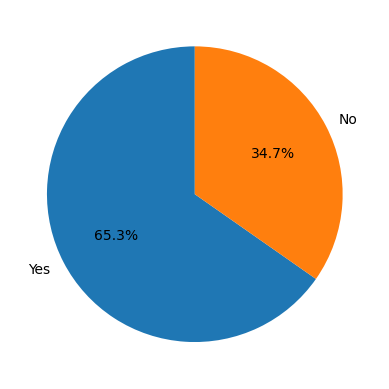

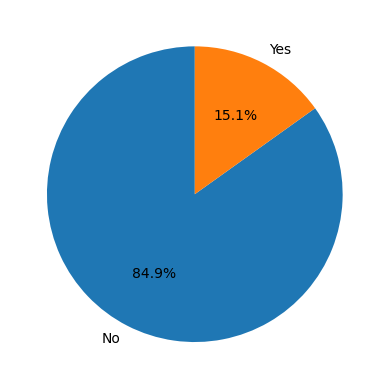

In [35]:
import plotly.graph_objects as go

def onlineoffline(df,col):

    val=df[col].value_counts().values
    label=df[col].value_counts().index
    plt.pie(val, labels = label,autopct='%1.1f%%', startangle = 90)
    # fig= go.Figure(data=[go.Pie(values=val,labels=label,textinfo="label+percent",insidetextorientation='radial',hole=.4,)])
    # fig.update_layout(title=f"{col}Status")
    plt.show()
onlineoffline(df,'online_order')
onlineoffline(df,'book_table')

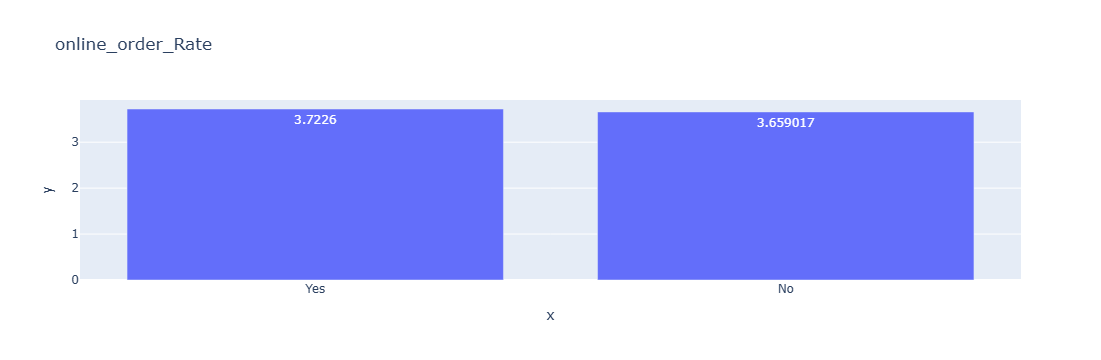

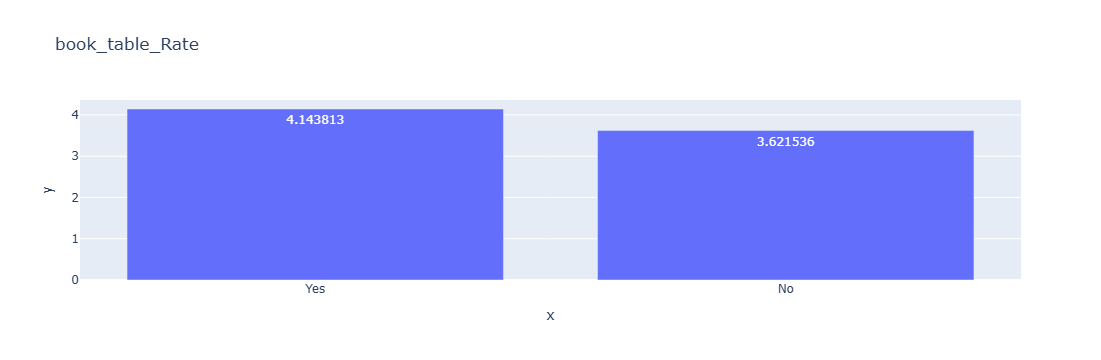

In [36]:
def online_offline_rate(df,col):
    
    fig= px.bar(x=df.index, y=df.values, text_auto=True,title = f"{col}_Rate")
    fig.show()

df_online= df.groupby(by='online_order')['rate'].mean().sort_values(ascending=False)
online_offline_rate(df_online,'online_order')

df_offline= df.groupby(by='book_table')['rate'].mean().sort_values(ascending=False)
online_offline_rate(df_offline,'book_table')



In [37]:
# def online_offline_rate(df,col):
    
#     fig= px.bar(x=df[col], y=df["count"], text_auto=True,title = f"{col}_Rate")
#     fig.update_layout(xaxis_title=col, yaxis_title="Count", title_x=0.5)
#     fig.show()

# df_online= df.groupby(by='online_order')['rate'].value_counts().sort_values(ascending=False).reset_index(name="count")
# online_offline_rate(df_online,'online_order')

# df_offline= df.groupby(by='book_table')['rate'].value_counts().sort_values(ascending=False).reset_index(name="count")
# online_offline_rate(df_offline,'book_table')

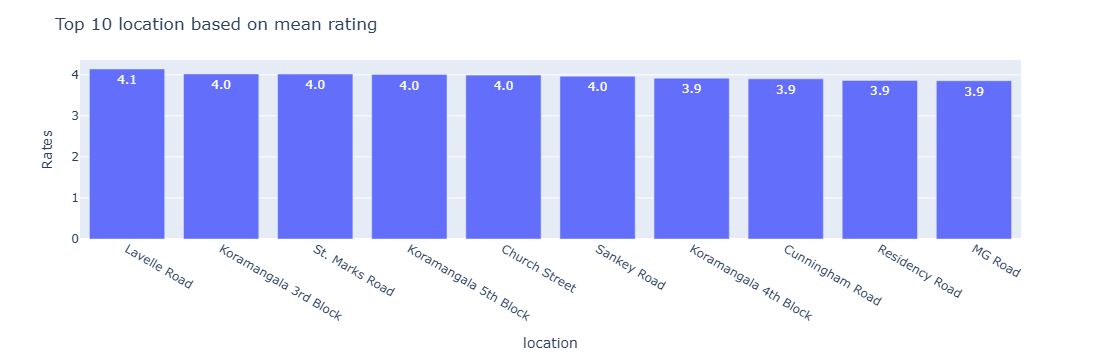

In [38]:
def top_10_location(df,col):
    label={"x":f'{col}', "y": "Rates"}
    x= df.groupby(col)['rate'].mean().nlargest(10)
    y=df.groupby(col)['rate'].mean().nlargest(10)
    fig=px.bar( x=x.index, y=y.values, text_auto='.2s',labels=label)
    fig.update_layout(title = f"Top 10 {col} based on mean rating")
    fig.show()

top_10_location(df,'location')

In [39]:
x= df['dish_liked'].value_counts()[:10].sort_values()

In [40]:
x

dish_liked
Burgers              33
Pizza                38
Rooftop Ambience     42
Coffee               42
Masala Dosa          56
Paratha              56
Chicken Biryani      66
Waffles              67
Friendly Staff       68
Biryani             180
Name: count, dtype: int64

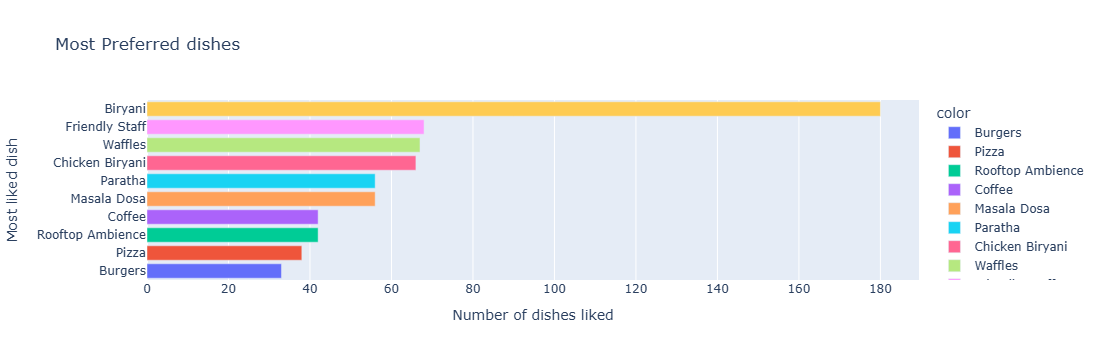

In [41]:
fig= px.bar(x=x, y=x.index, labels= {'x': 'Number of dishes liked','y': 'Most liked dish'},title='Most Preferred dishes',color=x.index)
fig.show()

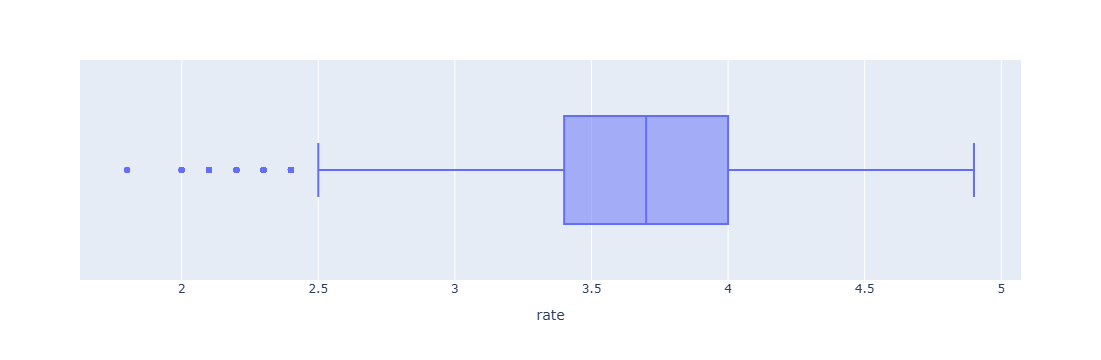

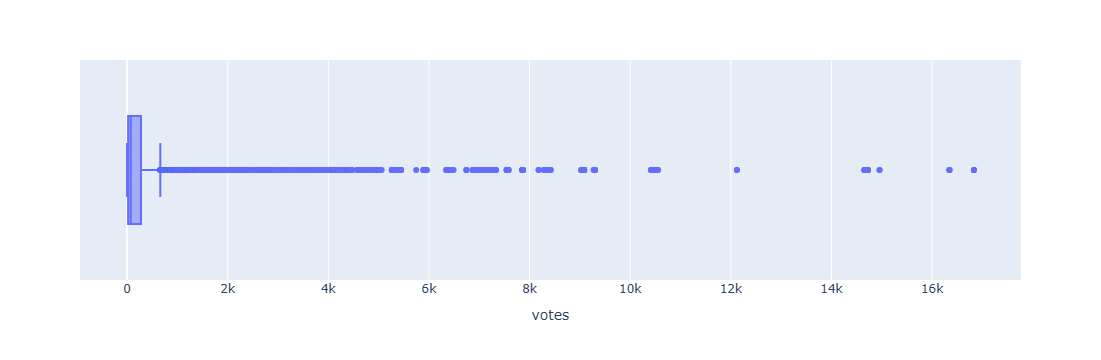

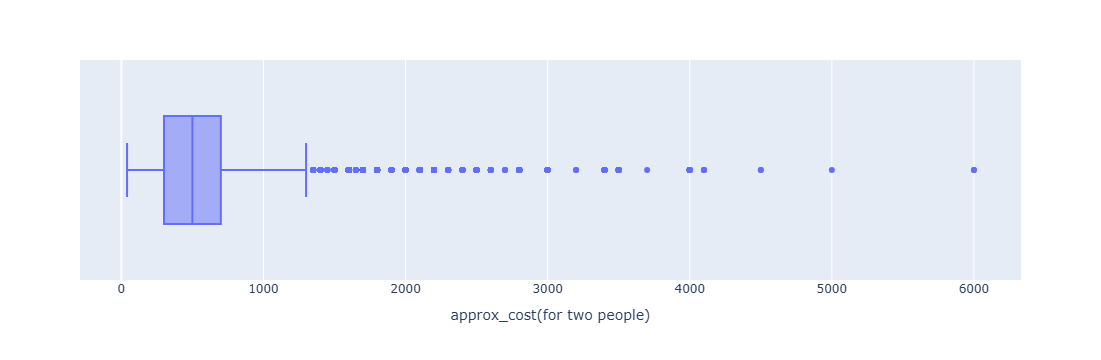

In [42]:
def outliers(df,col):
    fig=px.box(df, x=col)
    fig.show()

for col in numeric_cols:
    outliers(df,col)

In [43]:
df

,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...
51709,The Farm House Bar n Grill,No,No,3.7,34,Whitefield,"Casual Dining, Bar",NaN,"North Indian, Continental",800.0,"[('Rated 4.0', 'RATED\n Ambience- Big and spa...",Pubs and bars,Whitefield
51711,Bhagini,No,No,2.5,81,Whitefield,"Casual Dining, Bar","Biryani, Andhra Meal","Andhra, South Indian, Chinese, North Indian",800.0,"[('Rated 4.0', 'RATED\n A fine place to chill...",Pubs and bars,Whitefield
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,NaN,Continental,1500.0,"[('Rated 5.0', ""RATED\n Food and service are ...",Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,2500.0,"[('Rated 4.0', 'RATED\n Nice and friendly pla...",Pubs and bars,Whitefield


In [44]:
df.drop(["name","dish_liked","reviews_list"],axis=1,inplace=True)

In [45]:
X= df.drop('rate',axis=1)
y=df['rate']

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge,Lasso,ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import f_regression
from sklearn.feature_selection import mutual_info_regression ,SelectKBest


In [47]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,shuffle=True, random_state=42)

In [48]:
X_train.isna().sum()

online_order                     0
book_table                       0
votes                            0
location                         0
rest_type                      122
cuisines                        10
approx_cost(for two people)    194
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [49]:
X_train.rest_type.value_counts().sort_values().head(20)

rest_type
Dessert Parlor, Kiosk          1
Quick Bites, Kiosk             1
Dessert Parlor, Food Court     2
Food Court, Beverage Shop      2
Cafe, Food Court               2
Bakery, Food Court             2
Casual Dining, Quick Bites     3
Quick Bites, Meat Shop         3
Club, Casual Dining            3
Bhojanalya                     3
Fine Dining, Microbrewery      3
Quick Bites, Mess              4
Food Court, Casual Dining      4
Bar, Pub                       5
Bar, Lounge                    5
Food Court, Dessert Parlor     6
Casual Dining, Sweet Shop      7
Microbrewery, Lounge           8
Bar, Quick Bites               9
Casual Dining, Lounge         10
Name: count, dtype: int64

In [50]:
X_train.cuisines.value_counts().sort_values(ascending=False).head(20)

cuisines
North Indian                           1739
North Indian, Chinese                  1550
South Indian                            998
Cafe                                    501
Bakery, Desserts                        498
Biryani                                 475
South Indian, North Indian, Chinese     448
Desserts                                430
Fast Food                               425
Chinese                                 323
Ice Cream, Desserts                     302
Bakery                                  293
Chinese, North Indian                   272
Mithai, Street Food                     271
North Indian, Chinese, Biryani          214
Finger Food                             200
Desserts, Ice Cream                     195
Desserts, Beverages                     193
Chinese, Momos                          184
North Indian, South Indian              181
Name: count, dtype: int64

In [51]:
X_train['approx_cost(for two people)'].describe()

count    33103.000000
mean       604.205238
std        465.588987
min         40.000000
25%        300.000000
50%        500.000000
75%        750.000000
max       6000.000000
Name: approx_cost(for two people), dtype: float64

In [52]:
import numpy as np

In [53]:
fillvalue=SimpleImputer(missing_values = np.nan, strategy= "median")
X_train["approx_cost(for two people)"] = fillvalue.fit_transform(X_train["approx_cost(for two people)"].values.reshape(-1,1))[:,0]
X_test["approx_cost(for two people)"] = fillvalue.fit_transform(X_test["approx_cost(for two people)"].values.reshape(-1,1))[:,0]

fill_const = SimpleImputer(missing_values = np.nan, strategy= "constant")
X_train["rest_type"] = fill_const.fit_transform(X_train["rest_type"].values.reshape(-1,1))[:,0]
X_test["rest_type"] = fill_const.fit_transform(X_test["rest_type"].values.reshape(-1,1))[:,0]

fill_freq = SimpleImputer(missing_values = np.nan, strategy= "most_frequent")
X_train["cuisines"] = fill_const.fit_transform(X_train["cuisines"].values.reshape(-1,1))[:,0]
X_test["cuisines"] = fill_const.fit_transform(X_test["cuisines"].values.reshape(-1,1))[:,0]




In [54]:
X_train.isnull().sum(),X_test.isnull().sum()

(online_order                   0
 book_table                     0
 votes                          0
 location                       0
 rest_type                      0
 cuisines                       0
 approx_cost(for two people)    0
 listed_in(type)                0
 listed_in(city)                0
 dtype: int64,
 online_order                   0
 book_table                     0
 votes                          0
 location                       0
 rest_type                      0
 cuisines                       0
 approx_cost(for two people)    0
 listed_in(type)                0
 listed_in(city)                0
 dtype: int64)

In [55]:
encoder = OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value= -1)
X_train["location"] = encoder.fit_transform(X_train["location"].values.reshape(-1,1))[:,0]
X_train["rest_type"] = encoder.fit_transform(X_train["rest_type"].values.reshape(-1,1))[:,0]
X_train["cuisines"] = encoder.fit_transform(X_train["cuisines"].values.reshape(-1,1))
X_train["listed_in(city)"] = encoder.fit_transform(X_train["listed_in(city)"].values.reshape(-1,1))[:,0]

In [56]:
X_test["location"] = encoder.fit_transform(X_test["location"].values.reshape(-1,1))[:,0]
X_test["rest_type"] = encoder.fit_transform(X_test["rest_type"].values.reshape(-1,1))[:,0]
X_test["cuisines"] = encoder.fit_transform(X_test["cuisines"].values.reshape(-1,1))
X_test["listed_in(city)"] = encoder.fit_transform(X_test["listed_in(city)"].values.reshape(-1,1))[:,0]

In [57]:
X_train["online_order"].replace({'No':0,'Yes':1},inplace=True)
X_test["online_order"].replace({'No':0,'Yes':1},inplace=True)
X_train['book_table'].replace({'Yes' : 1, 'No': 0}, inplace= True)
X_test['book_table'].replace({'Yes' : 1, 'No': 0}, inplace= True)

X_train['listed_in(type)'].replace({'Delivery': 0,
                                    'Drinks & nightlife':1, 
                                   'Dine-out':2, 
                                   'Pubs and bars':3,
                                   'Cafes':4, 
                                   'Buffet':5, 
                                   'Desserts':6},inplace=True)
X_test['listed_in(type)'].replace({'Delivery': 0,
                                    'Drinks & nightlife':1, 
                                   'Dine-out':2, 
                                   'Pubs and bars':3,
                                   'Cafes':4, 
                                   'Buffet':5, 
                                   'Desserts':6},inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_17132\2253751842.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\HP\AppData\Local\Temp\ipykernel_17132\2253751842.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\HP\AppData\Local\Temp\ipykernel_17132\2253751842.py:2: FutureWarning:



In [58]:
X_train

,online_order,book_table,votes,location,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
32500,1,1,1155,22.0,23.0,1356.0,1800.0,0,18.0
47638,1,1,1943,51.0,23.0,2313.0,2100.0,0,27.0
8308,1,0,60,0.0,15.0,465.0,900.0,4,0.0
39909,0,1,174,69.0,23.0,2023.0,1200.0,0,22.0
42229,0,0,10,51.0,15.0,465.0,400.0,4,21.0
...,...,...,...,...,...,...,...,...,...
7783,1,0,45,9.0,13.0,290.0,300.0,2,6.0
14161,1,0,539,19.0,23.0,390.0,800.0,2,8.0
47372,1,0,93,20.0,72.0,2033.0,300.0,0,27.0
1007,1,0,23,29.0,72.0,2031.0,150.0,0,2.0


In [59]:
global linear_model_scores


In [60]:
lr = LinearRegression()
ridge= Ridge()
lasso= Lasso()
en=ElasticNet()

linear_models_list=[lr,ridge,lasso,en]

In [61]:
linear_models_scores = {}
def create_linear_models(model,X_train,X_test):
    model.fit(X_train,y_train)
    preds_train=model.predict(X_train)
    preds_test=model.predict(X_test)
    rmse_train=mean_squared_error(y_train,preds_train,squared=False)
    rmse_test=mean_squared_error(y_test,preds_test,squared=False)
    
    model_name=str(model).split("(")[0]
    print("MODEL NAME: ",model_name)
    print("TRAIN RMSE: ",rmse_train)
    print("TEST RMSE: ",rmse_test)
    print("*********************************")
    
    linear_models_scores.update({
      f"{model_name} Train RMSE": rmse_train,
      f"{model_name} Test RMSE": rmse_test
    })

In [62]:
for md in linear_models_list:
    create_linear_models(md,X_train,X_test)

MODEL NAME:  LinearRegression
TRAIN RMSE:  0.3679242811770107
TEST RMSE:  0.3659468605487344
*********************************
MODEL NAME:  Ridge
TRAIN RMSE:  0.3679242822325854
TEST RMSE:  0.3659476966859227
*********************************
MODEL NAME:  Lasso
TRAIN RMSE:  0.38167148895905784
TEST RMSE:  0.3814592878602586
*********************************
MODEL NAME:  ElasticNet
TRAIN RMSE:  0.380307951953713
TEST RMSE:  0.3804694966313887
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda

In [63]:
linear_models_scores

{'LinearRegression Train RMSE': 0.3679242811770107,
 'LinearRegression Test RMSE': 0.3659468605487344,
 'Ridge Train RMSE': 0.3679242822325854,
 'Ridge Test RMSE': 0.3659476966859227,
 'Lasso Train RMSE': 0.38167148895905784,
 'Lasso Test RMSE': 0.3814592878602586,
 'ElasticNet Train RMSE': 0.380307951953713,
 'ElasticNet Test RMSE': 0.3804694966313887}

In [128]:
rf=RandomForestRegressor()
xgr=XGBRegressor()
lgr=LGBMRegressor()
ensemble_models=[rf,xgr,lgr]

In [130]:
global ensemble_models_scores
ensemble_models_scores={}
global trained_models
trained_models=[]

In [132]:
#feature selection
def create_ensemble_models(model,X_train,X_test):
    model.fit(X_train,y_train)
    preds_train=model.predict(X_train)
    preds_test=model.predict(X_test)
    rmse_train=mean_squared_error(y_train,preds_train,squared=False)
    rmse_test=mean_squared_error(y_test,preds_test,squared=False)
    model_name=str(model).split("(")[0]
    
    print("MODEL NAME: ",model_name)
    print("TRAIN RMSE: ",rmse_train)
    print("TEST RMSE: ",rmse_test)
    print("*********************************")
    
    ensemble_models_scores.update({
      f"{model_name} Train RMSE": rmse_train,
      f"{model_name} Test RMSE": rmse_test
    })
    
    trained_models.append(model)

In [134]:
for md in ensemble_models:
    create_ensemble_models(md,X_train,X_test)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



MODEL NAME:  RandomForestRegressor
TRAIN RMSE:  0.049016100135000275
TEST RMSE:  0.2975375202609407
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



MODEL NAME:  XGBRegressor
TRAIN RMSE:  0.19161821502149565
TEST RMSE:  0.3342394564232509
*********************************
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 777
[LightGBM] [Info] Number of data points in the train set: 33297, number of used features: 9
[LightGBM] [Info] Start training from score 3.702469
MODEL NAME:  LGBMRegressor
TRAIN RMSE:  0.2523303916156721
TEST RMSE:  0.3290056817076246
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [136]:


def show_feature_importance_values(model,df):
    feature_importance = model.feature_importances_
    feature_names = df.columns  
    feature_importance_dict = dict(zip(feature_names, feature_importance))
    
    model_name=str(model).split("(")[0]

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(feature_importance_dict.values()), 
                y=list(feature_importance_dict.keys()))
    plt.xlabel(f'{model_name} Feature Importance Values')
    plt.ylabel('Features')
    plt.title(f'{model_name} Feature Importances Graph')
    plt.show()

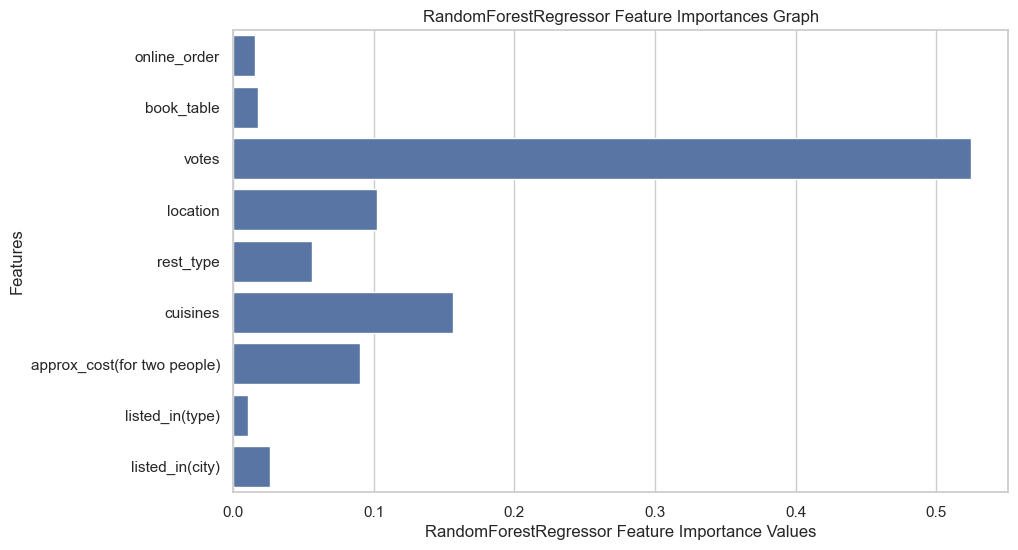

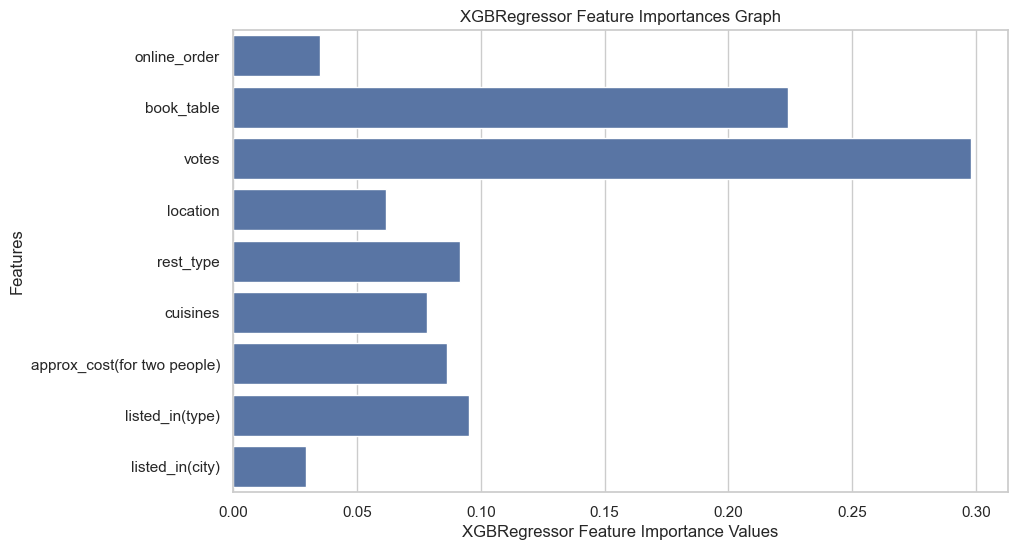

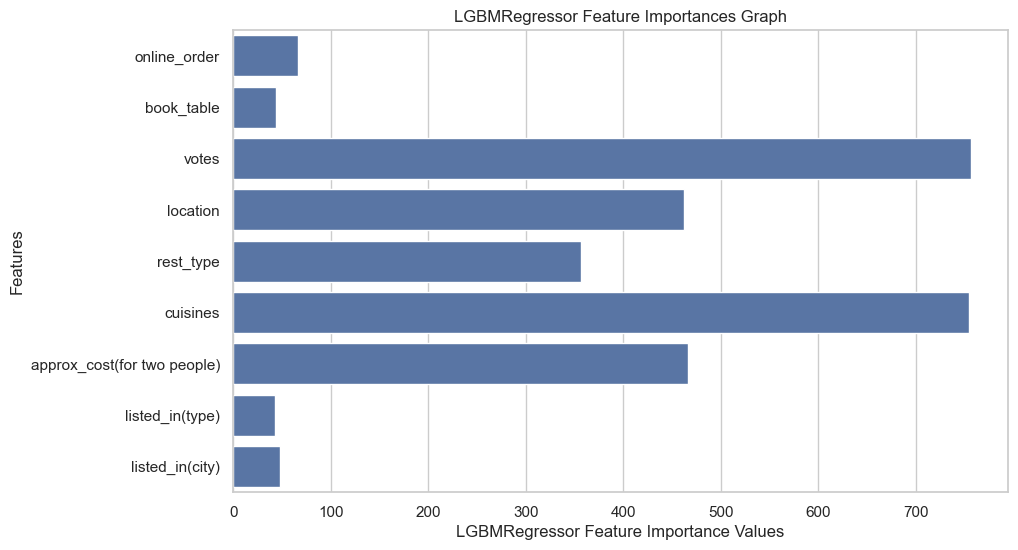

In [138]:
for m in trained_models:
    show_feature_importance_values(m,X_train)

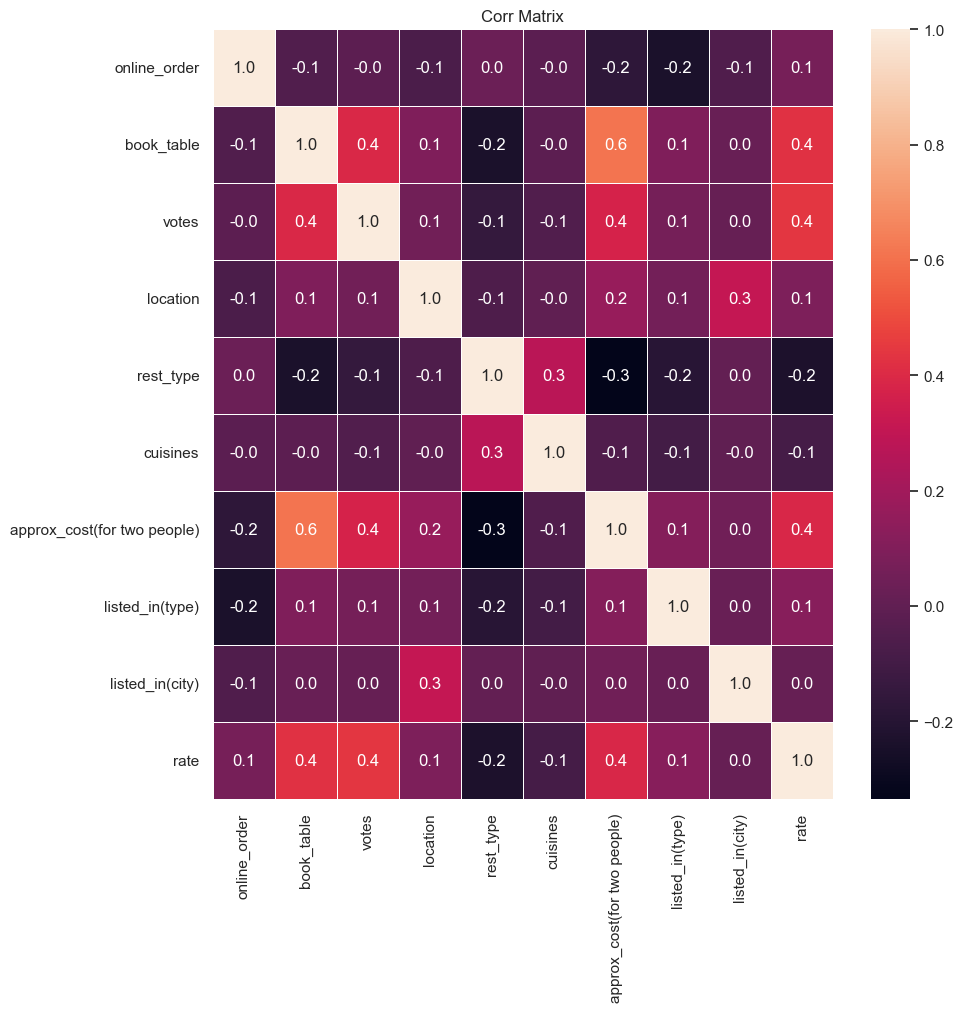

In [140]:
data=X_train.copy()
data["rate"]=y_train
corr=data.corr()
f,ax=plt.subplots(figsize=(10,10))
sns.heatmap(corr,annot=True,linewidths=0.5,fmt=".1f",ax=ax)
plt.title("Corr Matrix")
plt.show()

('online_order', 153.88433501582972)
('book_table', 7178.986739168739)
('votes', 7887.52441789941)
('location', 272.1115553450591)
('rest_type', 1879.3098710018667)
('cuisines', 287.8470756298507)
('approx_cost(for two people)', 5801.04004023057)
('listed_in(type)', 497.3675749863497)
('listed_in(city)', 6.83578591633369)


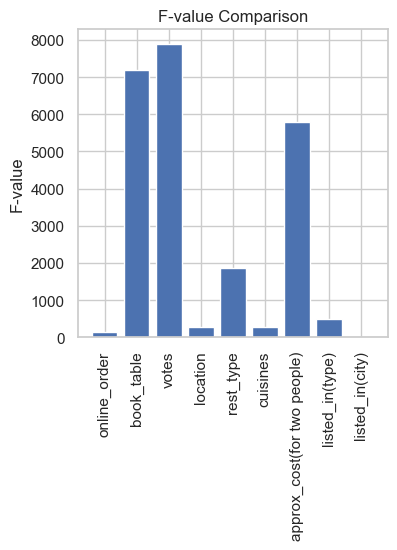

In [142]:
f_value = f_regression(X_train, y_train)

for feature in zip(X_train.columns, f_value[0]):
    print(feature)

plt.figure(figsize=(4,4))
plt.bar(x=X_train.columns, height=f_value[0])
plt.xticks(rotation='vertical')
plt.ylabel('F-value')
plt.title('F-value Comparison')
plt.show()

('online_order', 0.010585841251526062)
('book_table', 0.12428393252216807)
('votes', 0.8725428125279091)
('location', 0.1700830895930201)
('rest_type', 0.229241231470672)
('cuisines', 1.011405532670656)
('approx_cost(for two people)', 0.20316231566618725)
('listed_in(type)', 0.030936200411238346)
('listed_in(city)', 0.029562904178508376)


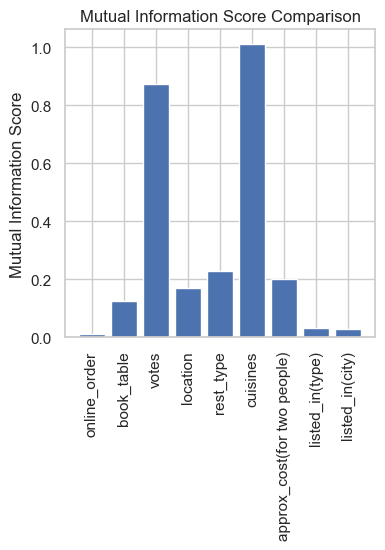

In [144]:
MI_score = mutual_info_regression(X_train, y_train, random_state=0)

# Print the name and mutual information score of each feature
for feature in zip(X_train.columns, MI_score):
    print(feature)
    
plt.figure(figsize=(4,4))
plt.bar(x=X_train.columns, height=MI_score)
plt.xticks(rotation='vertical')
plt.ylabel('Mutual Information Score')
plt.title('Mutual Information Score Comparison')

plt.show()

In [146]:
skb = SelectKBest(score_func=f_regression, k=5)                  
X_data_new = skb.fit_transform(X_train, y_train)

print('Number of features before feature selection: {}'.format(X_train.shape[1]))
print('Number of features after feature selection: {}'.format(X_data_new.shape[1]))

for feature_list_index in skb.get_support(indices=True):
    print('- ' + X_train.columns[feature_list_index])

Number of features before feature selection: 9
Number of features after feature selection: 5
- book_table
- votes
- rest_type
- approx_cost(for two people)
- listed_in(type)


In [150]:
drop_cols=['online_order','listed_in(city)']
X_train_new=X_train.drop(columns=drop_cols,axis=1)
X_test_new=X_test.drop(columns=drop_cols,axis=1)

In [152]:
linear_models_scores={}
for md in linear_models_list:
    create_linear_models(md,X_train_new,X_test_new)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda

MODEL NAME:  LinearRegression
TRAIN RMSE:  0.371874854789304
TEST RMSE:  0.3702120585401691
*********************************
MODEL NAME:  Ridge
TRAIN RMSE:  0.37187485588543157
TEST RMSE:  0.37021293875204864
*********************************
MODEL NAME:  Lasso
TRAIN RMSE:  0.38167148895905784
TEST RMSE:  0.3814592878602586
*********************************
MODEL NAME:  ElasticNet
TRAIN RMSE:  0.380307951953713
TEST RMSE:  0.3804694966313887
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [154]:
for md in ensemble_models:
    create_ensemble_models(md,X_train_new,X_test_new)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



MODEL NAME:  RandomForestRegressor
TRAIN RMSE:  0.04646073002953064
TEST RMSE:  0.3008681217632694
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



MODEL NAME:  XGBRegressor
TRAIN RMSE:  0.1946263998525511
TEST RMSE:  0.3336291575677143
*********************************
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000815 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 745
[LightGBM] [Info] Number of data points in the train set: 33297, number of used features: 7
[LightGBM] [Info] Start training from score 3.702469
MODEL NAME:  LGBMRegressor
TRAIN RMSE:  0.25281569276607824
TEST RMSE:  0.32396956236842067
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [156]:
feat_selection_ensemble_scores=ensemble_models_scores
feat_selection_ensemble_scores

{'RandomForestRegressor Train RMSE': 0.04646073002953064,
 'RandomForestRegressor Test RMSE': 0.3008681217632694,
 'XGBRegressor Train RMSE': 0.1946263998525511,
 'XGBRegressor Test RMSE': 0.3336291575677143,
 'LGBMRegressor Train RMSE': 0.25281569276607824,
 'LGBMRegressor Test RMSE': 0.32396956236842067}

In [160]:
#hyperparameter tunning
rf_params = {'bootstrap': [True, False],
 'criterion':['squared_error'],
 'max_depth': [5,7,10],
 'max_features':[0.3,0.5,0.7],  
 'min_samples_split':[0.3,0.5,0.7], 
 'n_estimators':[100,250,500,1000]
}

rf_model = RandomForestRegressor()

rsCV = RandomizedSearchCV(rf_model,rf_params, n_iter=20,cv=3, n_jobs=-1, verbose=0)
rsCV.fit(X_train_new, y_train)

print("Best hyperparams", rsCV.best_params_)
print("Best score:", rsCV.best_score_)

Best hyperparams {'n_estimators': 1000, 'min_samples_split': 0.3, 'max_features': 0.7, 'max_depth': 5, 'criterion': 'squared_error', 'bootstrap': False}
Best score: 0.4075557326315473


In [162]:
rf_model = RandomForestRegressor(**rsCV.best_params_) 
create_ensemble_models(rf_model,X_train_new,X_test_new)

MODEL NAME:  RandomForestRegressor
TRAIN RMSE:  0.33880009241138737
TEST RMSE:  0.3406443527811942
*********************************


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [164]:
lgb_params ={'learning_rate':[0.1,0.01,0.5],
             'n_estimators':[100,500,1000,1250],
             'colsample_bytree': [0.3,0.7,1],
             'max_bin':[100,250,300],
             'max_depth':[3,4,6],
             'min_data_in_leaf':[10,20,50],
             'reg_alpha': [1, 5, 10],
             'reg_lambda': [1, 5, 10],
             'min_gain_to_split':[1, 5, 10]
            }


lg_model = LGBMRegressor()
rsCV = RandomizedSearchCV(lg_model,lgb_params, n_iter=20,cv=3, n_jobs=-1, verbose=0)
rsCV.fit(X_train_new, y_train)

print("Best Hyperparams:", rsCV.best_params_)
print("Best Score:", rsCV.best_score_)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002747 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 33297, number of used features: 7
[LightGBM] [Info] Start training from score 3.702469
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

In [166]:
lg_model = LGBMRegressor(**rsCV.best_params_)
create_ensemble_models(lg_model,X_train_new,X_test_new)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_gain_to_split is set=1, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 834
[LightGBM] [Info] Number of data points in the train set: 33297, number of used features: 7
[LightGBM] [Info] Start training from score 3.702469
[LightGBM] [Warning] No further 

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning:

'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.



In [168]:
#After feature selection and hyperparameter optimization, reduced the diffrence between train and test error with using LightGBMClassifier